# Assignment 1: Wrangling and EDA
### Foundations of Machine Learning

In [72]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `airbnb_NYC.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? For the remaining missing values, replace the `np.nan/None` values with the label `Missing`.
3. Dummy variable: For `metabric.csv`, convert the `Overall Survival Status` variable into a dummy/binary variable, taking the value 0 if the patient is deceased and 1 if they are living.
4. Missing values: For `airbnb_NYC.csv`, determine how many missing values of `Review Scores Rating` there are. Create a new variable, in which you impute the median score for non-missing observations to the missing ones. Why might this bias or otherwise negatively impact your results?

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#1) numeric variable
df = pd.read_csv('data/airbnb_NYC.csv', encoding='latin1')

In [74]:
df["Price"].head()
#1) Removing the commas and apostraphes
df["Price_clean"] = (
    df["Price"]
    .str.replace("$", "")
    .str.replace(",", "")
)
#1) Converting into numeric values
df["Price_clean"] = pd.to_numeric(
    df["Price_clean"],
    errors="coerce"
)

In [75]:
#1) checking for missing values
df["Price_clean"].isna().sum()

np.int64(0)

In [76]:
#2) Loading new data
df2 = pd.read_csv('data/mn_police_use_of_force.csv', encoding='latin1')

df2["subject_injury"].value_counts(dropna=False)
df2["subject_injury_clean"] = (
    df2["subject_injury"]
    .str.strip()
    .str.title()
)
#2) Missing proportion
gone_values = df2["subject_injury_clean"].isna().mean()
gone_values
#2)cross tabulating
pd.crosstab(
    df2["force_type"],
    df2["subject_injury_clean"],
    dropna=False
)
#replacing values
df2["subject_injury_clean"] = df2["subject_injury_clean"].fillna("Missing")

In [77]:
#3) dummy variable
df3 = pd.read_csv('data/metabric.csv', encoding='latin1')
df3["survival_dummy"] = np.where(
    df3["Overall Survival Status"] == "Living",
    1,
    0
)
#3 check work
df3["survival_dummy"].value_counts()

,count
survival_dummy,
0,1343


In [78]:
#4 Missing Values
df["Review Scores Rating"].isna().sum()

np.int64(8323)

In [79]:
median = df["Review Scores Rating"].median()
median

94.0

In [80]:
df["Review_Scores_Rating_imputed"] = df["Review Scores Rating"].fillna(
    median
)

In [81]:
df["Review_Scores_Rating_imputed"].isna().sum()

np.int64(0)

median imputations likely are reducing the variance that we are seeing in our data

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work. What does work?
2. Drop any columns that do not contain data.
3. What is an observation? Carefully justify your answer, and explain how it affects your choices in cleaning and analyzing the data.
4. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
5. Clean the Age variable and make a histogram of the ages of the victims.
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Thoughts?

In [82]:
#1 Opening sharks file
sharks = pd.read_excel("/content/GSAF5.xls")

In [83]:
#2 Dropping data
sharks = sharks.dropna(axis=1, how="all")

In [84]:
#3 What is an observation? Carefully justify your answer, and explain how it affects your choices in cleaning and analyzing the data.
sharks["Year"].unique()
sharks["Year_clean"] = pd.to_numeric(sharks["Year"], errors="coerce")


Many of the shark attacks happened within the 1500s to early 2000s. I found this information by looking specifically at the years of shark attacks and that is the data information I was given.

In [85]:
# Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
sharks["Year_clean"].describe()

,Year_clean
count,7072.000000
mean,1936.004242
std,270.672015
min,0.000000
25%,1948.000000
50%,1987.000000
75%,2010.000000
max,2026.000000


<Axes: xlabel='Year_clean'>

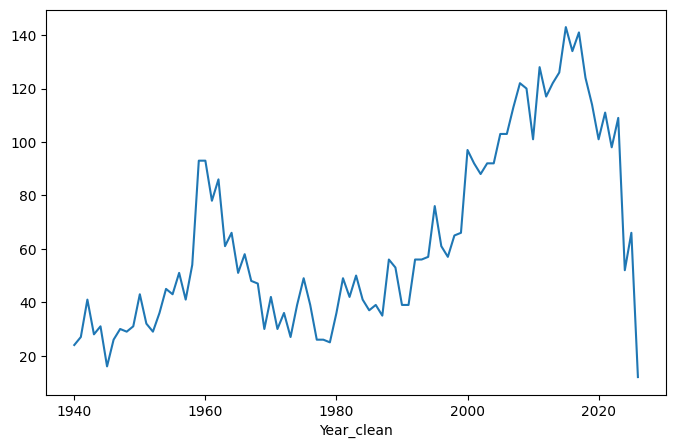

In [86]:
#4
sharks_1940 = sharks[sharks["Year_clean"] >= 1940]
attacks_per_year = sharks_1940.groupby("Year_clean").size()
attacks_per_year.plot(kind="line", figsize=(8, 5))

attacks increased until 1960 and was decreasing until 2000 where it increased

<Axes: >

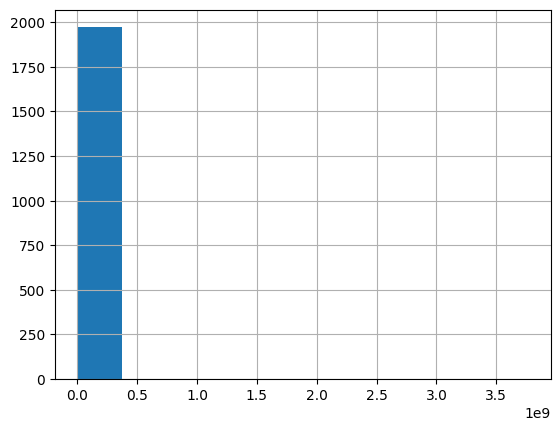

In [87]:
#5 Clean the Age variable and make a histogram of the ages of the victims.
sharks["Age_clean"] = (
    sharks["Age"]
    .str.replace(r"[^\d]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)
sharks["Age_clean"].hist(bins=10)

In [88]:
#6 Clean the Type variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
sharks["Age_clean"] = (
    sharks["Age"]
    .str.replace(r"[^\d]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

<Axes: >

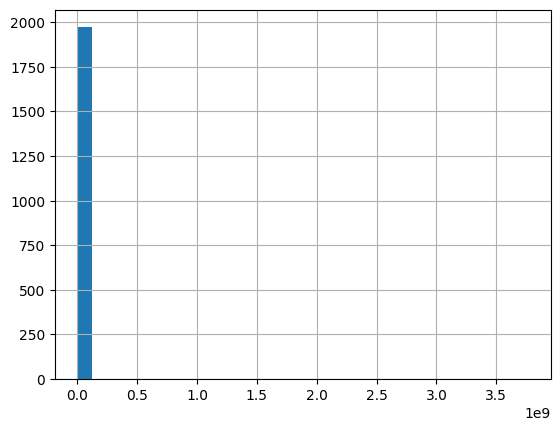

In [89]:
sharks["Age_clean"].hist(bins=30)

In [90]:
#7 Clean the Fatal Y/N variable so it only takes three values: Y, N, and Unknown.
sharks["Type"].value_counts(dropna=False)

,count
Type,
Unprovoked,5225
Provoked,642
Invalid,552
Watercraft,355
Sea Disaster,242
Questionable,26
NaN,18
Boat,7
Provoked,2


In [91]:
sharks["Type_clean"] = (
    sharks["Type"]
    .str.strip()
    .str.title()
)

sharks["Type_clean"] = sharks["Type_clean"].replace({
    "Provoked": "Provoked",
    "Unprovoked": "Unprovoked"
})
sharks["Type_clean"] = sharks["Type_clean"].where(
    sharks["Type_clean"].isin(["Provoked", "Unprovoked"]),
    "Unknown"
)

sharks["Type_clean"].value_counts(normalize=True)

,proportion
Type_clean,
Unprovoked,0.738762
Unknown,0.170201
Provoked,0.091038


In [92]:
#8 Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Thoughts?
sharks["Fatal Y/N"].value_counts(dropna=False)

sharks["Fatal_clean"] = (
    sharks["Fatal Y/N"]
    .str.strip()
    .str.upper()
)

sharks["Fatal_clean"] = sharks["Fatal_clean"].where(
    sharks["Fatal_clean"].isin(["Y", "N"]),
    "Unknown"
)

0.738 is the proportion of unprovoked shark attacks

**Q3.** Open the "tidy_data.pdf" document available in `https://github.com/ds4e/wrangling`, which is a paper called *Tidy Data* by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  2. Read the introduction. What is the "tidy data standard" intended to accomplish?
  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."
  4. Read Section 2.2. How does Wickham define values, variables, and observations?
  5. How is "Tidy Data" defined in section 2.3?
  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?
  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?

1) This paper focuses on data tidying. The datasets structure allows for easy datatools to be accessed in order to complete data analysis
2) designed to facilitate initial exploration and analysis of the data, and to simplify the development of the analysis tool that work together.
3)first section means that there overall format is the same for tidydataset, but the actual data is different. The second sentence is the gap between intuition of the data analyst and formal logic.
4)values is either numbers or strings
/ variables contains all values that measure the same underlying attribute across units/ observations contains all values measured on the same unit across attributes
5)tidy data each variable forms a column, each observation forms a row, and each type of observationan unti forms a table
6) most common problems is column headers are values, not variable names, multiple variables are stored in both rows and columns, multiple types of observational units are stored in the same table, a single observational unit is stored in multiple tables. Need to turn columns into rows to tidy. melt means turing columns into rows.
7) table 11 has lots of missing values while table 12 is tidy as it drops missing values to conserve space


**Q4.** This question looks at financial transfers from international actors to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going?

For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
5. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions.
6. Which giftors provide the most money, in total?

In [93]:
Gifts = pd.read_csv('data/ForeignGifts_edu.csv', encoding='latin1')

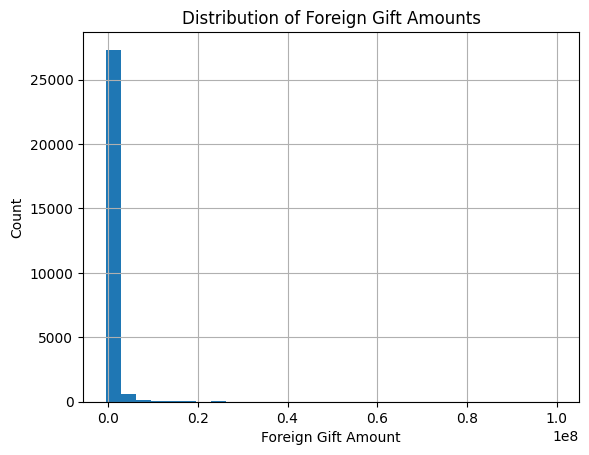

In [94]:
Gifts["Foreign Gift Amount"].describe()
Gifts["Foreign Gift Amount"].hist(bins=30)
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Count")
plt.title("Distribution of Foreign Gift Amounts")
plt.show()

the data is very centralized in one area and skewed to the left


In [95]:
#3
Gifts["Gift Type"].value_counts()
Gifts["Gift Type"].value_counts(normalize=True)

,proportion
Gift Type,
Contract,0.612097
Monetary Gift,0.387513
Real Estate,0.000390


In [96]:
#4
country_counts = (
    Gifts.groupby("Country of Giftor")
    .count()["Foreign Gift Amount"]
    .sort_values(ascending=False)
)
country_counts.head(15)

,Foreign Gift Amount
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [97]:
#4
country_amounts = (
    Gifts.groupby("Country of Giftor")
    .sum()["Foreign Gift Amount"]
    .sort_values(ascending=False)
)
country_amounts.head(15)

,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


In [98]:
#5
institution_amounts = (
    Gifts.groupby("Institution Name")
    .sum()["Foreign Gift Amount"]
    .sort_values(ascending=False)
)
institution_amounts.head(15)

,Foreign Gift Amount
Institution Name,
Carnegie Mellon University,1477922504
Cornell University,1289937761
Harvard University,954803610
Massachusetts Institute of Technology,859071692
Yale University,613441311
Texas A&M University,521455050
Johns Hopkins University,502409595
Northwestern University,402316221
Georgetown University,379950511


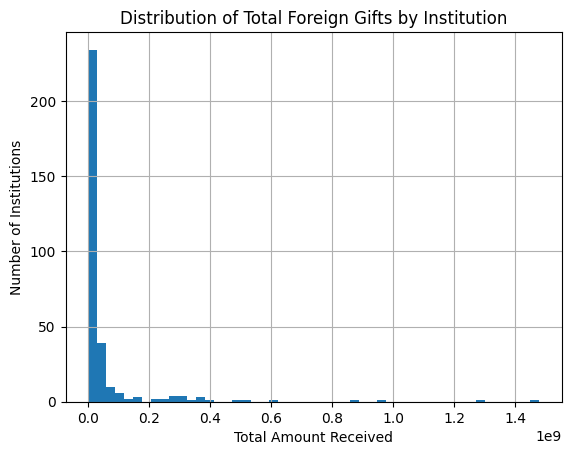

In [99]:
institution_amounts.hist(bins=50)
plt.xlabel("Total Amount Received")
plt.ylabel("Number of Institutions")
plt.title("Distribution of Total Foreign Gifts by Institution")
plt.show()

Carnegie Mellon University gifts the most

**Q5.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `college_completion.csv` dataset from the US Department of Education. The "relevant" variables for this question are:
  - `level` - Level of institution (4-year, 2-year)
  - `aid_value` - The average amount of student aid going to undergraduate recipients
  - `control` - Public, Private not-for-profit, Private for-profit
  - `grad_100_value` - percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions)

1. Load the `college_completion.csv` data with Pandas.
2. How many observations and variables are in the data? Use `.head()` to examine the first few rows of data.
3. Cross tabulate `control` and `level`. Describe the patterns you see in words.
4. For `grad_100_value`, create a kernel density plot and describe table. Now condition on `control`, and produce a kernel density plot and describe tables for each type of institutional control. Which type of institution appear to have the most favorable graduation rates?
5. Make a scatterplot of `grad_100_value` by `aid_value`, and compute the covariance and correlation between the two variables. Describe what you see. Now make the same plot and statistics, but conditioning on `control`. Describe what you see. For which kinds of institutions does aid seem to vary positively with graduation rates?

In [100]:
import seaborn as sns
college = pd.read_csv('data/college_completion.csv', encoding='latin1')
#This is observations
college.shape

(3798, 63)

In [101]:
#this is variables found 63
college.head()

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


In [102]:
#3
pd.crosstab(college["control"], college["level"])

level,2-year,4-year
control,,
Private for-profit,465,527
Private not-for-profit,68,1180
Public,926,632


4 yrs is much higher than within 2yrs

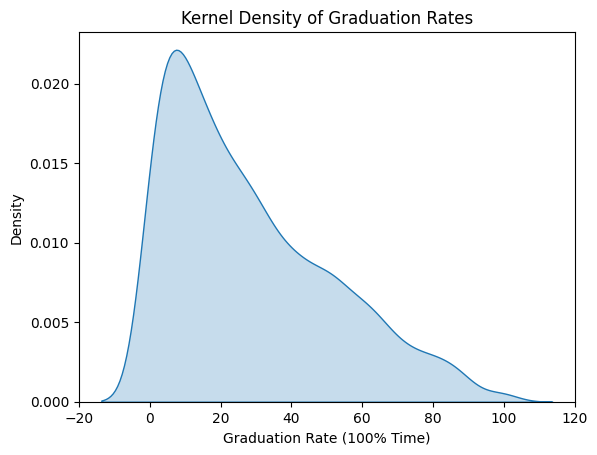

In [103]:
#4
sns.kdeplot(college["grad_100_value"], fill=True)
plt.xlabel("Graduation Rate (100% Time)")
plt.title("Kernel Density of Graduation Rates")
plt.show()

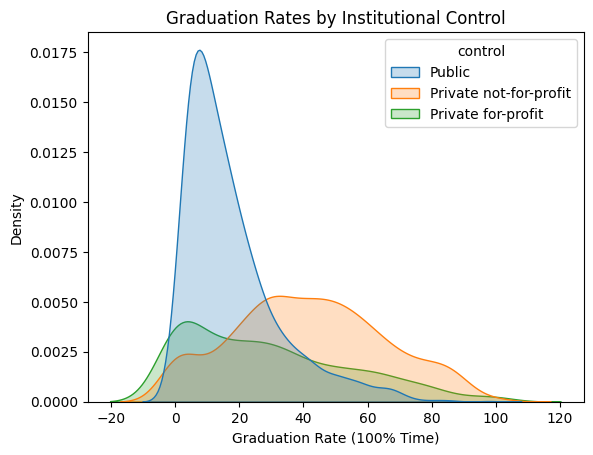

In [105]:
sns.kdeplot(
    data=college,
    x="grad_100_value",
    hue="control",
    fill=True
)
plt.xlabel("Graduation Rate (100% Time)")
plt.title("Graduation Rates by Institutional Control")
plt.show()

**Q6.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

We're going to look at **linear transformations** of $X$, $Y = a + bX$. So we take each value of $X$, $x_i$, and transform it as $y_i = a + b x_i$.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $ \text{cov}(X,X) = s^2$.
3. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
4. Show that $\text{cov}(a+bX,a+bY) = b^2 \text{cov}(X,Y) $. Notice, this also means that $\text{cov}(bX, bX) = b^2 s^2$.
5. Suppose $b>0$ and let the median of $X$ be $\text{med}(X)$. Is it true that the median of $a+bX$ is equal to $a + b \times \text{med}(X)$? Is the IQR of $a + bX$ equal to $a + b \times \text{IQR}(X)$?
6. Show by example that the means of $X^2$ and $\sqrt{X}$ are generally not $(m(X))^2$ and $\sqrt{m(X)}$. So, the results we derived above really depend on the linearity of the transformation $Y = a + bX$, and transformations like $Y = X^2$ or $Y = \sqrt{X}$ will not behave in a similar way.

In [107]:
#1)
X = np.array([1, 2, 3, 4, 5, 6])
a = 3
b = 2
Y = a + b * X

In [108]:
mean_X = np.mean(X)
mean_Y = np.mean(Y)

mean_Y, a + b * mean_X

(np.float64(10.0), np.float64(10.0))

In [110]:
variance_X = np.mean((X - mean_X) ** 2)
variance_X

cov_XX = np.mean((X - mean_X) * (X - mean_X))
cov_XX

np.float64(2.9166666666666665)

In [112]:
Z = a + b * Y
cov_XY = np.mean((X - np.mean(X)) * (Y - np.mean(Y)))
cov_XZ = np.mean((X - np.mean(X)) * (Z - np.mean(Z)))

cov_XZ, b * cov_XY

(np.float64(11.666666666666666), np.float64(11.666666666666666))

In [113]:
cov_transformed = np.mean(
    (a + b*X - np.mean(a + b*X)) *
    (a + b*Y - np.mean(a + b*Y))
)

cov_transformed, b**2 * cov_XY

(np.float64(23.333333333333332), np.float64(23.333333333333332))

In [114]:
median_X = np.median(X)
iqr_X = np.percentile(X, 75) - np.percentile(X, 25)

median_Y = np.median(Y)
iqr_Y = np.percentile(Y, 75) - np.percentile(Y, 25)

median_Y, a + b * median_X

(np.float64(10.0), np.float64(10.0))

**Q7.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `ames_prices.csv` dataset. The "relevant" variables for this question are:
  - `price` - Sale price value of the house
  - `Bldg.Type` - Building type of the house (single family home, end-of-unit townhome, duplex, interior townhome, two-family conversion)

1. Load the `college_completion.csv` data with Pandas.
2. Make a kernel density plot of price and compute a describe table. Now, make a kernel density plot of price conditional on building type, and use `.groupby()` to make a describe type for each type of building. Which building types are the most expensive, on average? Which have the highest variance in transaction prices?
3. Make an ECDF plot of price, and compute the sample minimum, .25 quantile, median, .75 quantile, and sample maximum (i.e. a 5-number summary).
4. Make a boxplot of price. Are there outliers? Make a boxplot of price conditional on building type. What patterns do you see?
5. Make a dummy variable indicating that an observation is an outlier.
6. Winsorize the price variable, and compute a new kernel density plot and describe table. How do the results change?

In [116]:
prices = pd.read_csv('/content/data/ames_prices.csv', encoding='latin1')


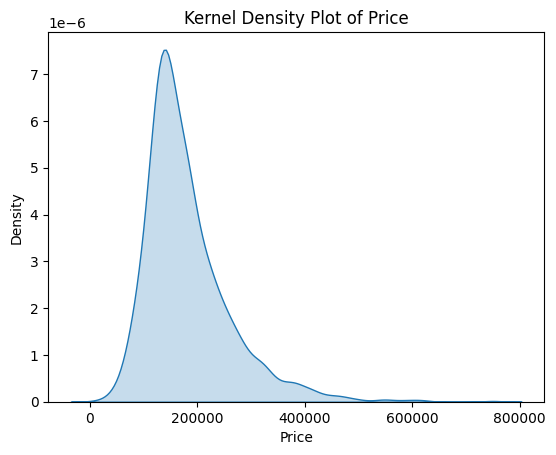

In [118]:
sns.kdeplot(prices["price"], fill=True)
plt.xlabel("Price")
plt.title("Kernel Density Plot of Price")
plt.show()

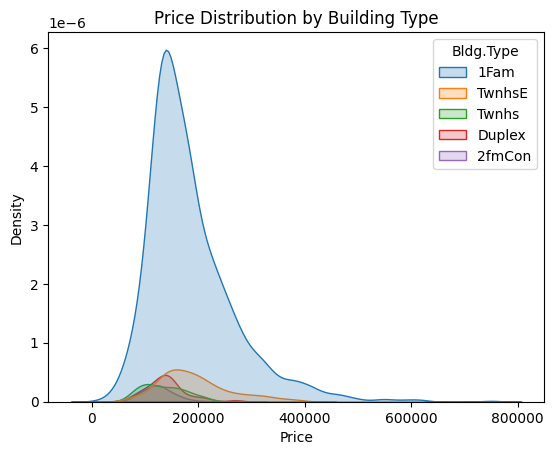

            count           mean           std      min       25%       50%  \
Bldg.Type                                                                     
1Fam       2425.0  184812.041237  82821.802329  12789.0  130000.0  165000.0   
2fmCon       62.0  125581.709677  31089.239840  55000.0  106562.5  122250.0   
Duplex      109.0  139808.935780  39498.973534  61500.0  118858.0  136905.0   
Twnhs       101.0  135934.059406  41938.931130  73000.0  100500.0  130000.0   
TwnhsE      233.0  192311.914163  66191.738021  71000.0  145000.0  180000.0   

                75%       max  
Bldg.Type                      
1Fam       220000.0  755000.0  
2fmCon     140000.0  228950.0  
Duplex     153337.0  269500.0  
Twnhs      170000.0  280750.0  
TwnhsE     222000.0  392500.0  


In [121]:
sns.kdeplot(
    data=prices,
    x="price",
    hue="Bldg.Type",
    fill=True
)
plt.xlabel("Price")
plt.title("Price Distribution by Building Type")
plt.show()

print(prices.groupby("Bldg.Type")["price"].describe())

In [ ]:
#highest is a 1 fam stay

In [125]:
price_by_type = prices.groupby("Bldg.Type")["price"].describe()
price_by_type

,count,mean,std,min,25%,50%,75%,max
Bldg.Type,,,,,,,,
1Fam,2425.0,184812.041237,82821.802329,12789.0,130000.0,165000.0,220000.0,755000.0
2fmCon,62.0,125581.709677,31089.239840,55000.0,106562.5,122250.0,140000.0,228950.0
Duplex,109.0,139808.935780,39498.973534,61500.0,118858.0,136905.0,153337.0,269500.0
Twnhs,101.0,135934.059406,41938.931130,73000.0,100500.0,130000.0,170000.0,280750.0
TwnhsE,233.0,192311.914163,66191.738021,71000.0,145000.0,180000.0,222000.0,392500.0


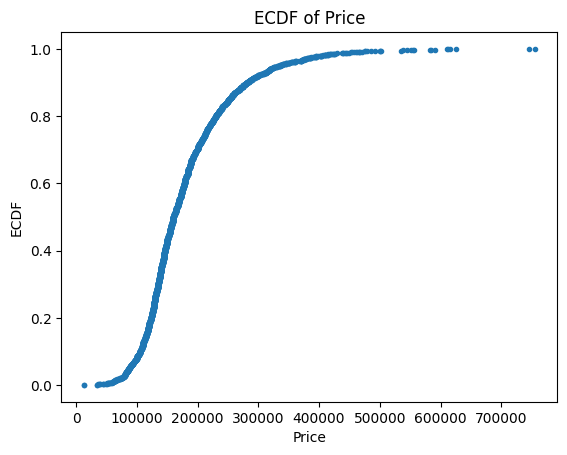

In [126]:
price_sorted = np.sort(prices["price"])
ecdf = np.arange(1, len(price_sorted) + 1) / len(price_sorted)

plt.plot(price_sorted, ecdf, marker=".", linestyle="none")
plt.xlabel("Price")
plt.ylabel("ECDF")
plt.title("ECDF of Price")
plt.show()

In [128]:
#summary
five = prices["price"].quantile([0, 0.25, 0.5, 0.75, 1])
five

,price
0.00,12789.0
0.25,129500.0
0.50,160000.0
0.75,213500.0
1.00,755000.0


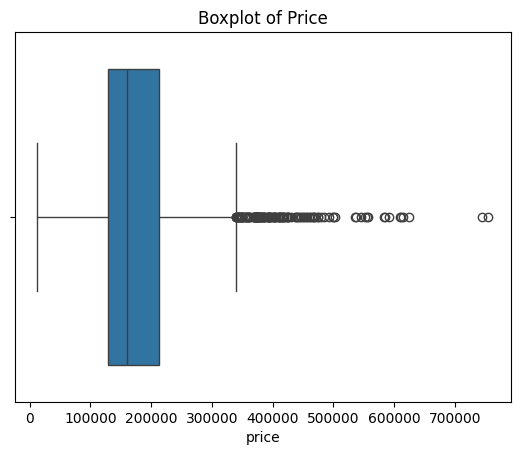

In [129]:
sns.boxplot(x=prices["price"])
plt.title("Boxplot of Price")
plt.show()

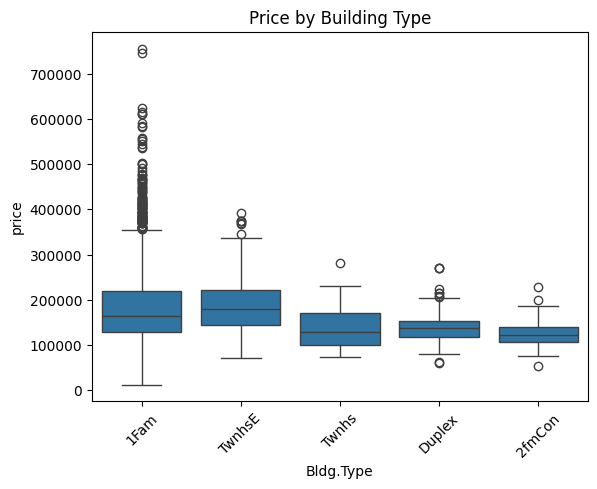

In [131]:
sns.boxplot(
    data=prices,
    x="Bldg.Type",
    y="price"
)
plt.xticks(rotation=45)
plt.title("Price by Building Type")
plt.show()

In [132]:
Q1 = prices["price"].quantile(0.25)
Q3 = prices["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [133]:
df["price_outlier"] = (
    (prices["price"] < lower_bound) |
    (prices["price"] > upper_bound)
).astype(int)

In [134]:
df["price_outlier"].value_counts()

,count
price_outlier,
0.0,2793
1.0,137


In [136]:
lower_w = prices["price"].quantile(0.05)
upper_w = prices["price"].quantile(0.95)

prices["price_winsor"] = prices["price"].clip(lower=lower_w, upper=upper_w)

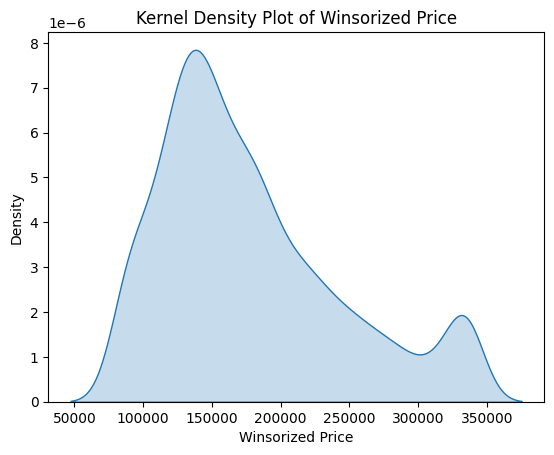

In [137]:
sns.kdeplot(prices["price_winsor"], fill=True)
plt.xlabel("Winsorized Price")
plt.title("Kernel Density Plot of Winsorized Price")
plt.show()

In [138]:
prices["price_winsor"].describe()

,price_winsor
count,2930.000000
mean,177632.528669
std,66195.453960
min,87500.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,335000.000000


We are seeing much more variance in our plot